In [2]:
!nvidia-smi

Fri Jan  9 16:46:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# 1. Install Ninja
!pip install -q ninja

# 2. Install the Roboflow version of GroundingDINO (more stable for Colab)
!pip install -q 'git+https://github.com/roboflow/GroundingDINO.git'

# 3. Install SAM and Supervision
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'
!pip install -q supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 24.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
import os
import torch
import cv2
import numpy as np
import supervision as sv
from groundingdino.util.inference import load_model, load_image, predict, annotate
from segment_anything import sam_model_registry, SamPredictor

# Set Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create weights directory and download model files
!mkdir -p weights
%cd weights
if not os.path.exists("groundingdino_swint_ogc.pth"):
    !wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth
if not os.path.exists("sam_vit_h_4b8939.pth"):
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
%cd ..

/content/weights
/content


In [5]:
import groundingdino
DINO_CONFIG_PATH = os.path.join(os.path.dirname(groundingdino.__file__), "config/GroundingDINO_SwinT_OGC.py")
DINO_CHECKPOINT_PATH = "weights/groundingdino_swint_ogc.pth"
SAM_CHECKPOINT_PATH = "weights/sam_vit_h_4b8939.pth"

# Load GroundingDINO
model = load_model(DINO_CONFIG_PATH, DINO_CHECKPOINT_PATH)

# Load SAM
sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT_PATH).to(device=DEVICE)
sam_predictor = SamPredictor(sam)

final text_encoder_type: bert-base-uncased


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [6]:
def auto_label_image(image_path, text_prompt):
    # Load Image
    image_source, image = load_image(image_path)

    # 1. GroundingDINO Detection
    boxes, logits, phrases = predict(
        model=model,
        image=image,
        caption=text_prompt,
        box_threshold=0.35,
        text_threshold=0.25
    )


    if len(boxes) == 0:
        print(f"⚠️ No objects found for prompt: '{text_prompt}'")
        # Return an empty detection object to prevent the crash
        return image_source, sv.Detections.empty()

    # 2. Setup SAM
    sam_predictor.set_image(image_source)

    # Convert boxes to pixel coordinates
    H, W, _ = image_source.shape
    boxes_xyxy = boxes * torch.Tensor([W, H, W, H])

    # 3. Generate Masks with SAM
    transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_xyxy, image_source.shape[:2]).to(DEVICE)

    masks, _, _ = sam_predictor.predict_torch(
        point_coords=None,
        point_labels=None,
        boxes=transformed_boxes,
        multimask_output=False,
    )

    # Combine results
    detections = sv.Detections(
        xyxy=boxes_xyxy.numpy(),
        confidence=logits.numpy(),
        class_id=np.zeros(len(boxes_xyxy), dtype=int),
        mask=masks.cpu().numpy().squeeze(1)
    )

    return image_source, detections

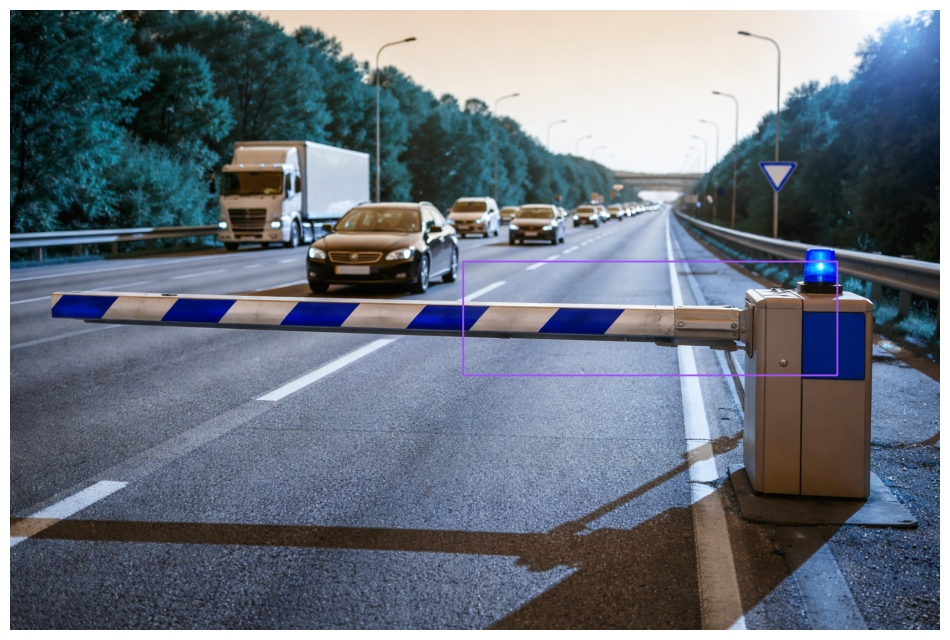

In [8]:
# RUN THE AUTO-LABELER
SOURCE_IMAGE_PATH = "sample_data/sample.png"
TEXT_PROMPT = "arm barrier"

image_source, detections = auto_label_image(SOURCE_IMAGE_PATH, TEXT_PROMPT)

# VISUALIZE
mask_annotator = sv.MaskAnnotator()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_frame = mask_annotator.annotate(scene=image_source.copy(), detections=detections)
annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)

%matplotlib inline
sv.plot_image(annotated_frame, (12, 12))

In [ ]:
import supervision as sv

dataset = sv.DetectionDataset(
    classes=["arm barrier"],  # Use the name of class you want to created labeled data
    images={SOURCE_IMAGE_PATH: image_source},
    annotations={SOURCE_IMAGE_PATH: detections}
)


dataset.as_yolo(
    images_directory_path="./dataset/images",
    annotations_directory_path="./dataset/labels",
    min_image_area_percentage=0.01
)

dataset.as_coco(
    images_directory_path="./dataset/images",
    annotations_path="./dataset/annotations.json"
)

print("✅ Exported labels in both YOLO (.txt) and COCO (.json) formats!")